<a href="https://colab.research.google.com/github/Bluedata-Consulting/GAAI-B4-Azure/blob/main/SELFLEARNING/code15_LangGraph-Hierarchical-Multi-Agent-Teams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hierarchical Multi-Agent Teams

## Overview
In this Notebook, we'll explore how to build a **Hierarchical Agent Team**.

We'll implement a hierarchical structure to break down complex tasks that are difficult to handle with a single agent or single-level supervisor. In this structure, each lower-level supervisor manages worker agents specialized in their respective domains.

This hierarchical approach helps efficiently solve complex tasks that would be overwhelming for a single worker or when there are too many workers to manage directly.

This example implements ideas from the [AutoGen paper](https://arxiv.org/abs/2308.08155) using ```LangGraph```, demonstrating how to organize two distinct teams for web research and document writing, managed through top and mid-level supervisors to oversee the entire process.

### Why Choose a **Hierarchical Agent Team**?

In our previous Supervisor example, we looked at how a single supervisor node assigns tasks to multiple worker nodes and consolidates their results. While this approach works well for simple cases, a hierarchical structure might be necessary in the following situations:

- **Increased Task Complexity**: A single supervisor may not be able to handle specialized knowledge required across various sub-domains simultaneously.
- **Growing Number of Workers**: When managing many workers, having a single supervisor directly command all workers can become overwhelming.

In such scenarios, we can create a hierarchical structure where higher-level supervisors delegate tasks to lower-level sub-supervisors, and each sub-supervisor then redistributes these tasks to their specialized worker teams.


### References
- [AutoGen paper: Enabling Next-Gen LLM Applications via Multi-Agent Conversation (Wu et al.)](https://arxiv.org/abs/2308.08155)
- [LangGraph - Multi-agent Systems](https://langchain-ai.github.io/langgraph/concepts/multi_agent/)

----

In [1]:
!sudo apt-get install graphviz-dev -y
!sudo apt-get install build-essential python3-dev -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
libgraphviz-dev is already the newest version (2.42.2-9ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libgl1-amber-dri libglapi-mesa
Use 'sudo apt autoremove' to remove them.
0 upgraded, 0 newly installed, 0 to remove and 88 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.10ubuntu1).
python3-dev is already the newest version (3.12.3-0ubuntu2).
The following packages were automatically installed and are no longer required:
  libgl1-amber-dri libglapi-mesa
Use 'sudo apt autoremove' to remove them.
0 upgraded, 0 newly installed, 0 to remove and 88 not upgraded.


In [2]:
!python -m pip install -U langchain-opentutorial beautifulsoup4  langchain_experimental langchain_tavily --quiet
!python -m pip install grandalf langchain langchain-core langgraph pyppeteer nest-asyncio pygraphviz --quiet

In [3]:
!pyppeteer-install

chromium is already installed.


In [4]:
from dotenv import load_dotenv

# Load API key information
load_dotenv(override=True)

True

## Building Tools

Each team consists of one or more agents, and each agent is equipped with one or more tools. Below, we'll define all the tools that will be used by various teams.
Let's first look at the research team.

### ResearchTeam Tools

The ResearchTeam can use search engines and URL scrapers to find information on the web. You can freely add additional features below to enhance the ResearchTeam's performance.

In [5]:
import re
from typing import List
from bs4 import BeautifulSoup
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_tavily import TavilySearch

# Define search tool (TavilySearch)
# Create a search tool instance that returns up to 6 results
tavily_tool = TavilySearch(k=6)


# Define tool for scraping detailed information from web pages
@tool
def scrape_webpages(urls: List[str]) -> str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    # Load web pages using the provided URL list
    loader = WebBaseLoader(
        web_path=urls,
        header_template={
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/102.0.0.0 Safari/537.36",
        },
    )
    docs = loader.load()

    def clean_text(html: str) -> str:
        soup = BeautifulSoup(html, "html.parser")
        text = soup.get_text(separator=" ").strip()
        return re.sub(r'\s+', ' ', text)  # Remove excessive whitespace

    # Create a string containing titles and content of loaded documents
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "").strip()}">\n{clean_text(doc.page_content)}\n</Document>'
            for doc in docs
        ]
    )

USER_AGENT environment variable not set, consider setting it to identify your requests.


### Document Writing Team Tools

Next, we'll define the tools (file access tools) that the document writing team will use.
These tools allow agents to access the file system, which may not be secure. Therefore, caution is needed when using them.

In [6]:
from pathlib import Path
from typing import Dict, Optional, List
from typing_extensions import Annotated

# Create temporary directory and set working directory
WORKING_DIRECTORY = Path("./tmp")

# Create tmp folder if it doesn't exist
WORKING_DIRECTORY.mkdir(exist_ok=True)


# Create and save outline
@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"


# Read document
@tool
def read_document(
    file_name: Annotated[str, "File path to read the document."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is not None:
        start = 0
    return "\n".join(lines[start:end])


# Write and save document
@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"


# Edit document
@tool
def edit_document(
    file_name: Annotated[str, "File path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ],
) -> Annotated[str, "File path of the edited document."]:
    """Edit a document by inserting text at specific line numbers."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    # Process insertions in order
    sorted_inserts = sorted(inserts.items())

    # Insert text at specified line numbers
    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    # Save edited document to file
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"

Finally, let's define the code execution tool, ```PythonREPLTool```:

In [7]:
from langchain_experimental.tools import PythonREPLTool

# PythonREPL tool
python_repl_tool = PythonREPLTool()

## Implementing Utility Functions for Multiple Agents
Here's how we create utility functions to streamline our tasks.

We'll use the ```functools.partial``` function from our previous tutorial to create agent nodes, specifically for:

1. Creating ```worker agents```
2. Creating ```supervisors``` for ```sub-graphs```

In [8]:
from langgraph.graph import START, END
from langchain_core.messages import HumanMessage
from langchain_openai import AzureChatOpenAI


# Agent Factory Class
class AgentFactory:
    def __init__(self, model_name):
        self.llm = AzureChatOpenAI(model=model_name, temperature=0)

    def create_agent_node(self, agent, name: str):
        # Node creation function
        def agent_node(state):
            result = agent.invoke(state)
            return {
                "messages": [
                    HumanMessage(content=result["messages"][-1].content, name=name)
                ]
            }

        return agent_node


# Initialize LLM
MODEL_NAME = "gpt4o"
llm = AzureChatOpenAI(model=MODEL_NAME, temperature=0)

# Create Agent Factory instance
agent_factory = AgentFactory(MODEL_NAME)

Here's an example of creating an agent node using the ```AgentFactory```. Let's look at how to create a search agent:

In [9]:
from langgraph.prebuilt import create_react_agent

# Define agent
search_agent = create_react_agent(llm, tools=[tavily_tool])
# Create agent node
search_node = agent_factory.create_agent_node(search_agent, name="Searcher")

Next is the function for creating a Team Supervisor:

In [10]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import AzureChatOpenAI
from pydantic import BaseModel
from typing import Literal


def create_team_supervisor(model_name, system_prompt, members) -> str:
    # Define list of options for next worker
    options_for_next = ["FINISH"] + members

    # Define response model for worker selection
    class RouteResponse(BaseModel):
        next: Literal[*options_for_next]

    # Create ChatPromptTemplate
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            MessagesPlaceholder(variable_name="messages"),
            (
                "system",
                "Given the conversation above, who should act next? "
                "Or should we FINISH? Select one of: {options}",
            ),
        ]
    ).partial(options=str(options_for_next))

    # Initialize LLM
    llm = AzureChatOpenAI(model=model_name, temperature=0)

    # Combine prompt and LLM to create chain
    supervisor_chain = prompt | llm.with_structured_output(RouteResponse)

    return supervisor_chain

## Defining Agent Teams
Let's define the Research Team and Doc Writing Team.

### Research Team

The research team has two worker nodes: a ```search agent``` and a ```research_agent``` responsible for ```web scraping```. Let's create these and set up their team supervisor:

In [11]:
import operator
from typing import List, TypedDict
from typing_extensions import Annotated

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai.chat_models import AzureChatOpenAI
from langgraph.prebuilt import create_react_agent


# Define state
class ResearchState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]  # Messages
    team_members: List[str]  # List of member agents
    next: str  # Instructions for Supervisor agent to select next worker


# Initialize LLM
llm = AzureChatOpenAI(model=MODEL_NAME, temperature=0)

# Create search node
search_agent = create_react_agent(llm, tools=[tavily_tool])
search_node = agent_factory.create_agent_node(search_agent, name="Searcher")

# Create web scraping node
web_scraping_agent = create_react_agent(llm, tools=[scrape_webpages])
web_scraping_node = agent_factory.create_agent_node(
    web_scraping_agent, name="WebScraper"
)

# Create Supervisor agent
supervisor_agent = create_team_supervisor(
    MODEL_NAME,
    "You are a supervisor tasked with managing a conversation between the"
    " following workers: Search, WebScraper. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH.",
    ["Searcher", "WebScraper"],
)

Finally, let's define a function to select the next node for routing:

In [12]:
def get_next_node(x):
    return x["next"]

### Creating Research Team Graph

Creates a workflow where a supervisor coordinates web search and scraping tasks.

In [13]:
from langchain_opentutorial.graphs import visualize_graph
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver

In [14]:
# Create graph
web_research_graph = StateGraph(ResearchState)

# Add nodes
web_research_graph.add_node("Searcher", search_node)
web_research_graph.add_node("WebScraper", web_scraping_node)
web_research_graph.add_node("Supervisor", supervisor_agent)

# Add edges
web_research_graph.add_edge("Searcher", "Supervisor")
web_research_graph.add_edge("WebScraper", "Supervisor")

# Define conditional edges: move to next node based on Supervisor's decision
web_research_graph.add_conditional_edges(
    "Supervisor",
    get_next_node,
    {"Searcher": "Searcher", "WebScraper": "WebScraper", "FINISH": END},
)

# Set entry point
web_research_graph.set_entry_point("Supervisor")

# Compile graph
web_research_app = web_research_graph.compile(checkpointer=MemorySaver())

# Visualize graph
#visualize_graph(web_research_app)
mermaid_code = web_research_app.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	Searcher(Searcher)
	WebScraper(WebScraper)
	Supervisor(Supervisor)
	__end__([<p>__end__</p>]):::last
	Searcher --> Supervisor;
	Supervisor -.-> Searcher;
	Supervisor -.-> WebScraper;
	Supervisor -. &nbsp;FINISH&nbsp; .-> __end__;
	WebScraper --> Supervisor;
	__start__ --> Supervisor;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [15]:
from IPython.display import display, Image

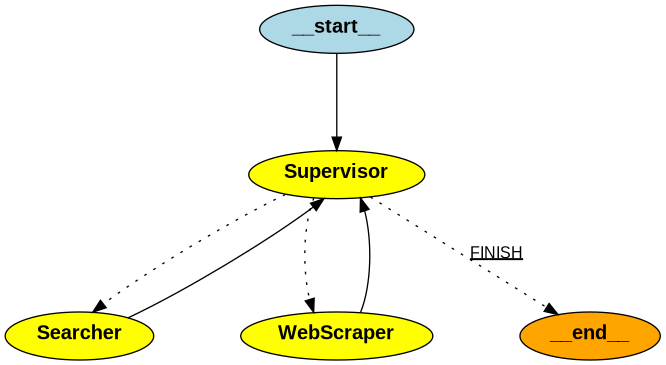

In [16]:
Image(web_research_app.get_graph().draw_png())

Let's run the ```web_research_app```:

In [17]:
from langchain_core.runnables import RunnableConfig
from langchain_opentutorial.messages import random_uuid, invoke_graph


def run_graph(app, message: str, recursive_limit: int = 50):
    # Set configuration
    config = RunnableConfig(
        recursion_limit=recursive_limit, configurable={"thread_id": random_uuid()}
    )

    # Prepare input
    inputs = {
        "messages": [HumanMessage(content=message)],
    }

    # Execute graph and display output
    invoke_graph(app, inputs, config)

    return app.get_state(config).values

In [18]:
output = run_graph(
    web_research_app,
    "Please summarize the main news from https://finance.yahoo.com/ and include the sources (URLs).",
)


🔄 Node: Supervisor 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
next:
WebScraper

🔄 Node: agent in [WebScraper] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  scrape_webpages (call_VQBP6Sh7ZzU10vby7MdJLFqz)
 Call ID: call_VQBP6Sh7ZzU10vby7MdJLFqz
  Args:
    urls: ['https://finance.yahoo.com/']

🔄 Node: tools in [WebScraper] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: scrape_webpages

<Document name="Yahoo Finance - Stock Market Live, Quotes, Business & Finance News">
Yahoo Finance - Stock Market Live, Quotes, Business & Finance News Something went wrong Skip to navigation Skip to main content Skip to right column News Today's news US Politics World Weather Climate change Health Wellness Mental health Sexual health Dermatology Oral health Hair loss Foot health Nutrition Healthy eatin

In [19]:
# Print final result
print(output["messages"][-1].content)

Here are the main news highlights from Yahoo Finance:

1. **US Stock Market Futures**: Futures for the Dow, S&P 500, and Nasdaq are mixed as the government shutdown continues, causing uncertainty in the markets. (Source: [Yahoo Finance](https://finance.yahoo.com/))

2. **Economic Data Delays**: The ongoing government shutdown is expected to delay the release of key economic data, including September's jobs report. ADP reported a decrease of 32,000 jobs in private payrolls last month. (Source: [Yahoo Finance](https://finance.yahoo.com/))

3. **Housing Market Trends**: Million-dollar homes are reportedly the fastest-moving segment in the housing market, indicating a shift in buyer preferences. (Source: [Yahoo Finance](https://finance.yahoo.com/))

4. **Corporate Developments**: Walmart plans to remove artificial dyes from its private-label foods, reflecting a growing trend towards healthier food options. (Source: [Yahoo Finance](https://finance.yahoo.com/))

5. **Market Reactions**: Wall

### Document Writing Team
Now let's create the document writing team. Here, we'll grant different file-writing tool access to each agent.

In [20]:
import operator
from typing import List, TypedDict, Annotated
from pathlib import Path

# Create temporary directory and set working directory
WORKING_DIRECTORY = Path("./tmp")
WORKING_DIRECTORY.mkdir(exist_ok=True)  # Create tmp folder if it doesn't exist


# Define state
class DocWritingState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: str
    next: str
    current_files: str  # Currently working files


# State preprocessing node: Helps each agent better recognize current working directory state
def preprocess(state):
    # Initialize list of written files
    written_files = []

    try:
        # Search all files in working directory and convert to relative paths
        written_files = [
            f.relative_to(WORKING_DIRECTORY) for f in WORKING_DIRECTORY.rglob("*")
        ]
    except Exception:
        pass

    # Add "No files written." to state if no files exist
    if not written_files:
        return {**state, "current_files": "No files written."}

    # Add list of written files to state
    return {
        **state,
        "current_files": "\nBelow are files your team has written to the directory:\n"
        + "\n".join([f" - {f}" for f in written_files]),
    }


# Initialize LLM
llm = AzureChatOpenAI(model=MODEL_NAME)

# Create document writing agent
doc_writer_agent = create_react_agent(
    llm,
    tools=[write_document, edit_document, read_document],
    prompt="You are a arxiv researcher. Your mission is to write arxiv style paper on given topic/resources.",
)
context_aware_doc_writer_agent = preprocess | doc_writer_agent
doc_writing_node = agent_factory.create_agent_node(
    context_aware_doc_writer_agent, name="DocWriter"
)

# Create note taking node
note_taking_agent = create_react_agent(
    llm,
    tools=[create_outline, read_document],
    prompt="You are an expert in creating outlines for research papers. Your mission is to create an outline for a given topic/resources or documents.",
)
context_aware_note_taking_agent = preprocess | note_taking_agent
note_taking_node = agent_factory.create_agent_node(
    context_aware_note_taking_agent, name="NoteTaker"
)

# Create chart generating agent
chart_generating_agent = create_react_agent(
    llm, tools=[read_document, python_repl_tool]
)
context_aware_chart_generating_agent = preprocess | chart_generating_agent
chart_generating_node = agent_factory.create_agent_node(
    context_aware_chart_generating_agent, name="ChartGenerator"
)

# Create document writing team supervisor
doc_writing_supervisor = create_team_supervisor(
    MODEL_NAME,
    "You are a supervisor tasked with managing a conversation between the"
    " following workers: ['DocWriter', 'NoteTaker', 'ChartGenerator']. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH.",
    ["DocWriter", "NoteTaker", "ChartGenerator"],
)

### Creating Doc Writing Team Graph

Integrates document writing, note-taking, and chart generation into a unified flow.

In [21]:
# Create graph
authoring_graph = StateGraph(DocWritingState)

# Define nodes
authoring_graph.add_node("DocWriter", doc_writing_node)
authoring_graph.add_node("NoteTaker", note_taking_node)
authoring_graph.add_node("ChartGenerator", chart_generating_node)
authoring_graph.add_node("Supervisor", doc_writing_supervisor)

# Define edges
authoring_graph.add_edge("DocWriter", "Supervisor")
authoring_graph.add_edge("NoteTaker", "Supervisor")
authoring_graph.add_edge("ChartGenerator", "Supervisor")

# Define conditional edges: Move to next node based on Supervisor node's decision
authoring_graph.add_conditional_edges(
    "Supervisor",
    get_next_node,
    {
        "DocWriter": "DocWriter",
        "NoteTaker": "NoteTaker",
        "ChartGenerator": "ChartGenerator",
        "FINISH": END,
    },
)

# Set entry point
authoring_graph.set_entry_point("Supervisor")

# Compile graph
authoring_app = authoring_graph.compile(checkpointer=MemorySaver())

Let's visualize the graph:

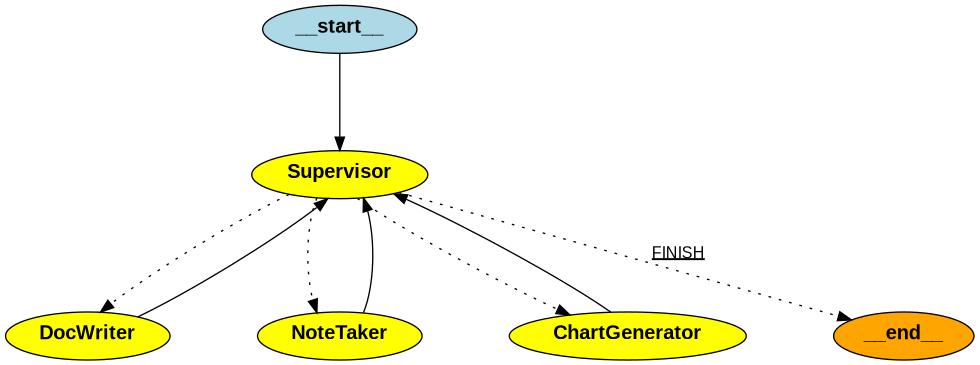

In [22]:

Image(authoring_app.get_graph().draw_png())

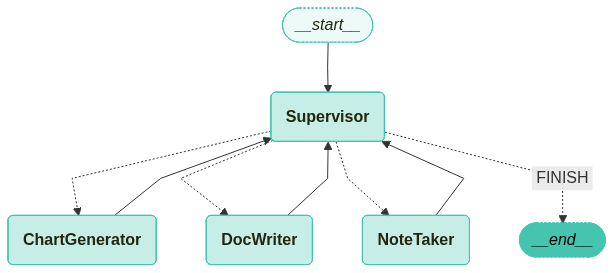

In [23]:
# Visualize graph
visualize_graph(authoring_app)

Now, let's run the graph and check the results:

In [24]:
output = run_graph(
    authoring_app,
    "Please do an in-depth analysis of the Transformer architecture and create a table of contents."
    "Then write at least 5 sentences for each section. "
    "If charts are needed for detailed explanations, please create them. "
    "Save the final results. ",
)


🔄 Node: Supervisor 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
next:
DocWriter

🔄 Node: agent in [DocWriter] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  write_document (call_sONOVFtdr7l4VpZcWRd9M0eF)
 Call ID: call_sONOVFtdr7l4VpZcWRd9M0eF
  Args:
    content: # Transformer Architecture: An In-Depth Analysis

## Table of Contents
1. Introduction  
2. Background  
   2.1. Sequence-to-Sequence Models  
   2.2. Limitations of Recurrent Neural Networks  
3. Overview of Transformer Architecture  
   3.1. Encoder-Decoder Structure  
   3.2. Attention Mechanism  
4. Components of Transformer  
   4.1. Multi-Head Attention  
   4.2. Positional Encoding  
   4.3. Feed Forward Neural Networks  
   4.4. Layer Normalization  
5. Training and Optimization  
   5.1. Loss Function  
   5.2. Optimization Algorithms  
   5.3. Regularization Techniques  
6. Applications of Transformers  
   

## Structuring a Super-Graph

This design implements a bottom-up planning policy. Although we've already created two graphs, we need to determine how to route tasks between them.

For this purpose, we'll define a **Super-Graph** to coordinate these two existing graphs and add connecting elements that define how this higher-level state is shared between different graphs. First, let's create the chief supervisor node:

In [25]:
from langchain_core.messages import BaseMessage
from langchain_openai.chat_models import AzureChatOpenAI

# Create ChatOpenAI instance as the base LLM
llm = AzureChatOpenAI(model=MODEL_NAME)

# Create team supervisor node
supervisor_node = create_team_supervisor(
    MODEL_NAME,
    "You are a supervisor tasked with managing a conversation between the"
    " following teams: ['ResearchTeam', 'PaperWritingTeam']. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH.",
    ["ResearchTeam", "PaperWritingTeam"],
)

Next, we'll define the state and nodes of the Super-Graph.

The Super-Graph primarily serves to route tasks between teams.

In [26]:
from typing import TypedDict, List, Annotated
import operator


# Define state
class State(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    # Routing decision
    next: str


# Node for returning the last message
def get_last_message(state: State) -> str:
    last_message = state["messages"][-1]
    if isinstance(last_message, str):
        return {"messages": [HumanMessage(content=last_message)]}
    else:
        return {"messages": [last_message.content]}


# Node for consolidating responses
def join_graph(response: dict):
    # Extract the last message and return as a message list
    return {"messages": [response["messages"][-1]]}

### Defining the Super-Graph

Now, let's define a Super-Graph that connects the two teams.

In [27]:
# Define graph
super_graph = StateGraph(State)

# Define nodes
super_graph.add_node("ResearchTeam", get_last_message | web_research_app | join_graph)
super_graph.add_node("PaperWritingTeam", get_last_message | authoring_app | join_graph)
super_graph.add_node("Supervisor", supervisor_node)

# Define edges
super_graph.add_edge("ResearchTeam", "Supervisor")
super_graph.add_edge("PaperWritingTeam", "Supervisor")

# Add conditional edges: Move to next node based on Supervisor's decision
super_graph.add_conditional_edges(
    "Supervisor",
    get_next_node,
    {
        "PaperWritingTeam": "PaperWritingTeam",
        "ResearchTeam": "ResearchTeam",
        "FINISH": END,
    },
)

# Set Supervisor node as the entry point
super_graph.set_entry_point("Supervisor")

# Compile graph
super_graph = super_graph.compile(checkpointer=MemorySaver())

Let's visualize the graph:

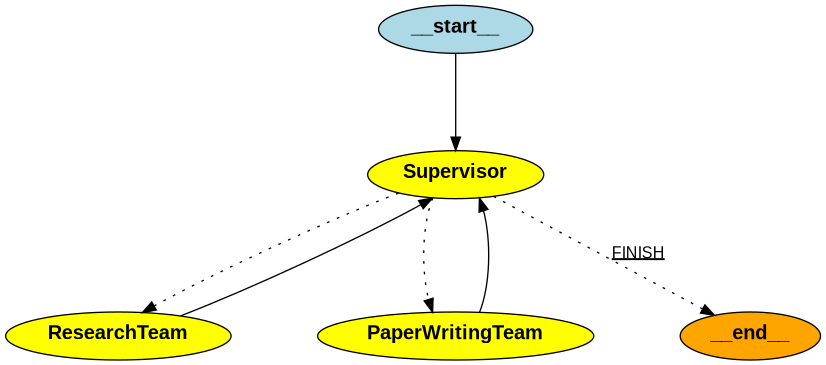

In [28]:

Image(super_graph.get_graph().draw_png())

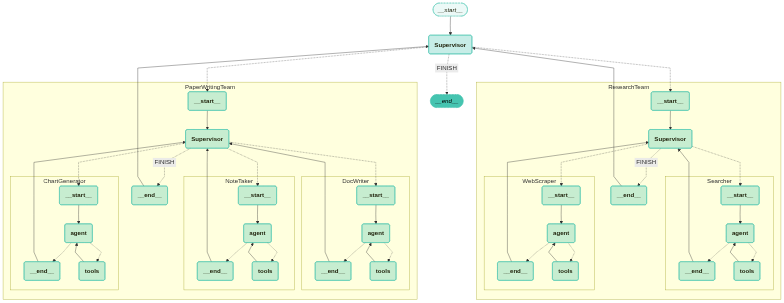

In [29]:
# Visualize graph
visualize_graph(super_graph, xray=True)

In [30]:
output = run_graph(
    super_graph,
    """Topic: How to perform complex tasks using multi-agent architecture

Detailed guidelines:
- Generate a report in Arxiv paper format on the topic.
- Create a comprehensive outline that covers all major aspects of the topic, such as introduction, background, methodology, applications, challenges, and conclusions.
- For each section of the outline, write at least 5 detailed sentences that explain the key concepts, theories, and practical applications involved.
- Ensure that for sections where applicable, you create and add charts or diagrams that help clarify complex ideas, such as relationships between agents, tasks, and processes.
- Provide detailed explanations on how multi-agent architecture can be used to solve real-world complex tasks, and include relevant examples and case studies where possible.
- Cite academic papers, articles, and other reliable sources in APA format throughout the content.
- Ensure each section is written in full (not just the outline) and the final document contains substantial content in line with the requested guidelines.
- Save the final result as a .md file with all the content fully populated, including the references section in APA format at the end.
""",
    recursive_limit=150,
)


🔄 Node: Supervisor 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
next:
ResearchTeam

🔄 Node: Supervisor in [ResearchTeam] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
next:
Searcher

🔄 Node: agent in [Searcher] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_7ZmqYwPS7tLlYyp7NeiUS0sK)
 Call ID: call_7ZmqYwPS7tLlYyp7NeiUS0sK
  Args:
    query: multi-agent architecture complex tasks
    search_depth: advanced

🔄 Node: tools in [Searcher] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: tavily_search

{"query": "multi-agent architecture complex tasks", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "http://www.lyzr.ai/blog/multi-agent-architecture/", "title": "Multi-Agent Architecture – How Intelligent Systems Work ...", "content": "Mu

Display the final result in Markdown format:

In [37]:
# Check the filename generated by the execution in the directory, and update the `md_file` variable below accordingly.
from IPython.display import Markdown

md_file = (
    "tmp/transformer_architecture_analysis.md"  # Update the filename here if necessary.
)
with open(md_file, "r", encoding="utf-8") as f:
    display(Markdown(f.read()))

1. 1. Introduction to Transformer Architecture
2. 2. Historical Context
3. 3. Key Components of Transformer Architecture
4. 4. Self-Attention Mechanism
5. 5. Positional Encoding
6. 6. Encoder-Decoder Structure
7. 7. Multi-Head Attention
8. 8. Applications of Transformers
9. 9. Challenges and Limitations
10. 10. Future Directions and Research Opportunities
11. 11. Conclusion
